# Introduction
A real-world dataset often contains anomalies or outlier data points. The cause of anomalies may be data corruption, experimental or human errors. The presence of anomalies may impact the performance of the model, hence to train a robust data science model, the dataset should be free from anomalies.

# What are Anomalies?
Anomalies are data points that stand out amongst other data points in the dataset and do not confirm the normal behavior in the data. These data points or observations deviate from the dataset’s normal behavioral patterns.

Anomaly detection is an unsupervised data processing technique to detect anomalies from the dataset. An anomaly can be broadly classified into different categories:

* Outliers: Short/small anomalous patterns that appear in a non-systematic way in data collection.
* Change in Events: Systematic or sudden change from the previous normal behavior.
* Drifts: Slow, undirectional, long-term change in the data.

Anomalies detection are very useful to detect fraudulent transactions, disease detection, or handle any case studies with high-class imbalance. Anomalies detection techniques can be used to build more robust data science models.

# How to detect Anomalies?
Simple statistical techniques such as mean, median, quantiles can be used to detect univariate anomalies feature values in the dataset. Various data visualization and exploratory data analysis techniques can be also be used to detect anomalies.

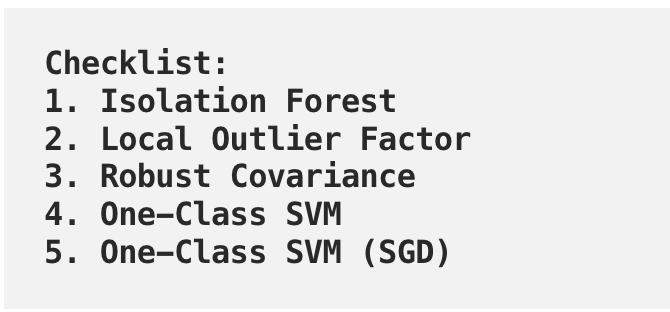

# “Why is anomaly detection so hard?”
Anomaly (or outlier) detection is the task of identifying data points that are “very strange” compared to the majority of observations.

This is useful in a range of applications, from fault detection to discovery of financial frauds, from finding health issues to identifying unsatisfied customers. Moreover, it can also be beneficial for machine learning pipelines, since it has been proven that removing outliers leads to an increase in model accuracy.

What makes anomaly detection so hard is that it is an unsupervised problem. In other words, we usually don’t have labels telling us which instances are actually “anomalies”. Or rather, even if we had labels, it would be very hard to frame anomaly detection as a supervised problem. In fact:

* anomalies are rare;
* anomalies are novel;
* anomalies are different from each other.

For all these reasons, supervised techniques typically make a bad fit with anomaly detection.

Being an outlier, Jeff Bezos is easier to isolate: it’s enough to ask “is he worth more than 170 billion $?” to retrieve him among almost 8 billion humans. On the other hand, since I am by far more ordinary than Jeff Bezos, you would probably need at least 10 True/False question to narrow down the search space until you find me.

## Looking under the hood
Now that we have seen the main intuition behind Isolation Forest, let’s try to understand the exact mechanics of the algorithm, with the aid of some simple data points.



In [1]:
import pandas as pd
df = pd.DataFrame({
    'x': [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 2.0],
    'y': [2.1, 2.4, 3.0, 2.6, 2.2, 2.8, 3.7]
}, index = ['A', 'B', 'C', 'D', 'E', 'F', 'G'])

<AxesSubplot:xlabel='x', ylabel='y'>

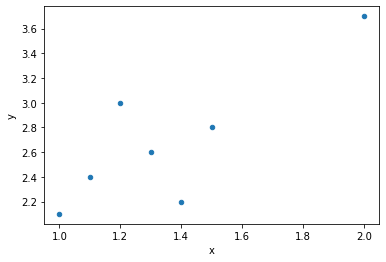

In [2]:
df.plot.scatter(x="x", y="y")

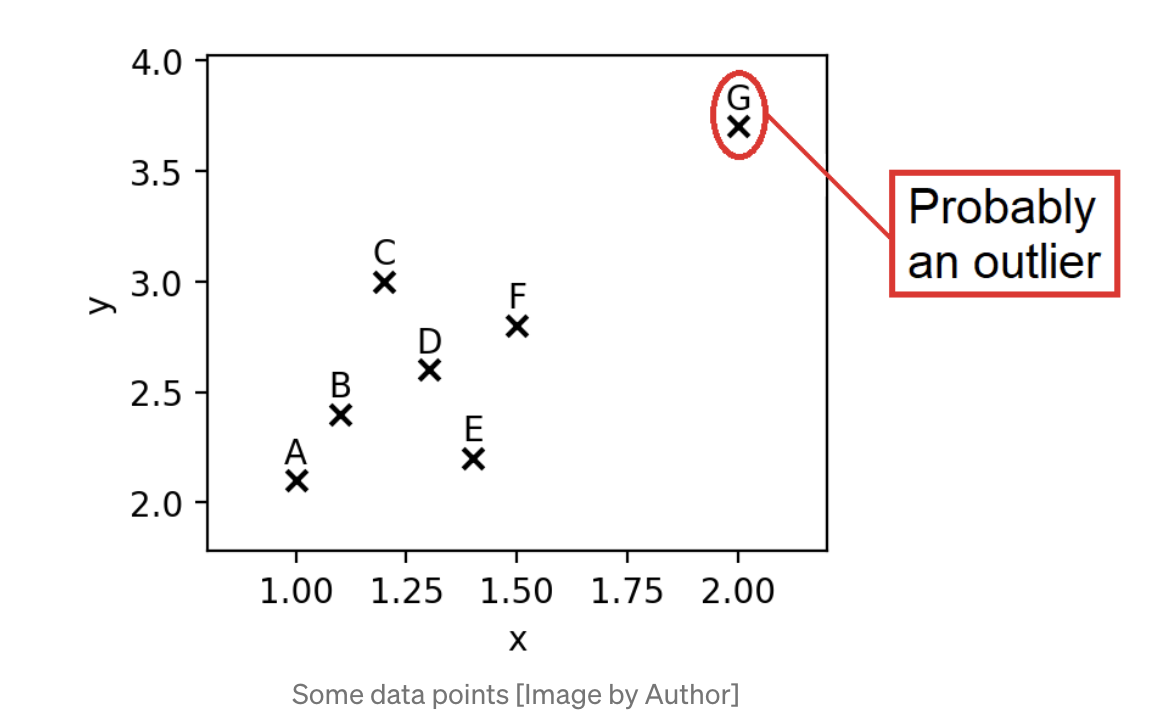

Items from A to F represent a quite compact cloud of points: they are “normal” data points. Compared to these instances, G is probably an outlier: it has anomalous values both for x and y.

Isolation Forest is based on trees, so let’s fit a tree on these data:



The most fundamental concept here is the depth of the leaf at which each element is found. For example, in this tree, the observation called G (our outlier) is at depth 1 (e.g. 1 level from the root node), whereas C is at depth 3.

**The idea behind Isolation Forest is that, on average, outliers will be closer to the root node (i.e. at a lower depth) than normal instances.**

As often in machine learning, the key is iteration. In fact, if we randomly fit many decision trees, and then take an average of the depth of each observation over the different trees, we find an “average depth” that represents an empirical measure of “outlierness”.



# Isolation Forest in Scikit-learn
Let’s see an example of usage through the Scikit-learn’s implementation.

In [3]:
from sklearn.ensemble import IsolationForest
iforest = IsolationForest(n_estimators = 100).fit(df)

If we take the first 9 trees from the forest (iforest.estimators_[:9]) and plot them, this is what we get:

In [4]:
iforest.estimators_[:9]

[ExtraTreeRegressor(max_depth=3, max_features=1, random_state=1116200618),
 ExtraTreeRegressor(max_depth=3, max_features=1, random_state=1764131932),
 ExtraTreeRegressor(max_depth=3, max_features=1, random_state=1890418398),
 ExtraTreeRegressor(max_depth=3, max_features=1, random_state=1706799864),
 ExtraTreeRegressor(max_depth=3, max_features=1, random_state=1500912158),
 ExtraTreeRegressor(max_depth=3, max_features=1, random_state=1434256180),
 ExtraTreeRegressor(max_depth=3, max_features=1, random_state=2111699995),
 ExtraTreeRegressor(max_depth=3, max_features=1, random_state=1957388701),
 ExtraTreeRegressor(max_depth=3, max_features=1, random_state=1875479120)]

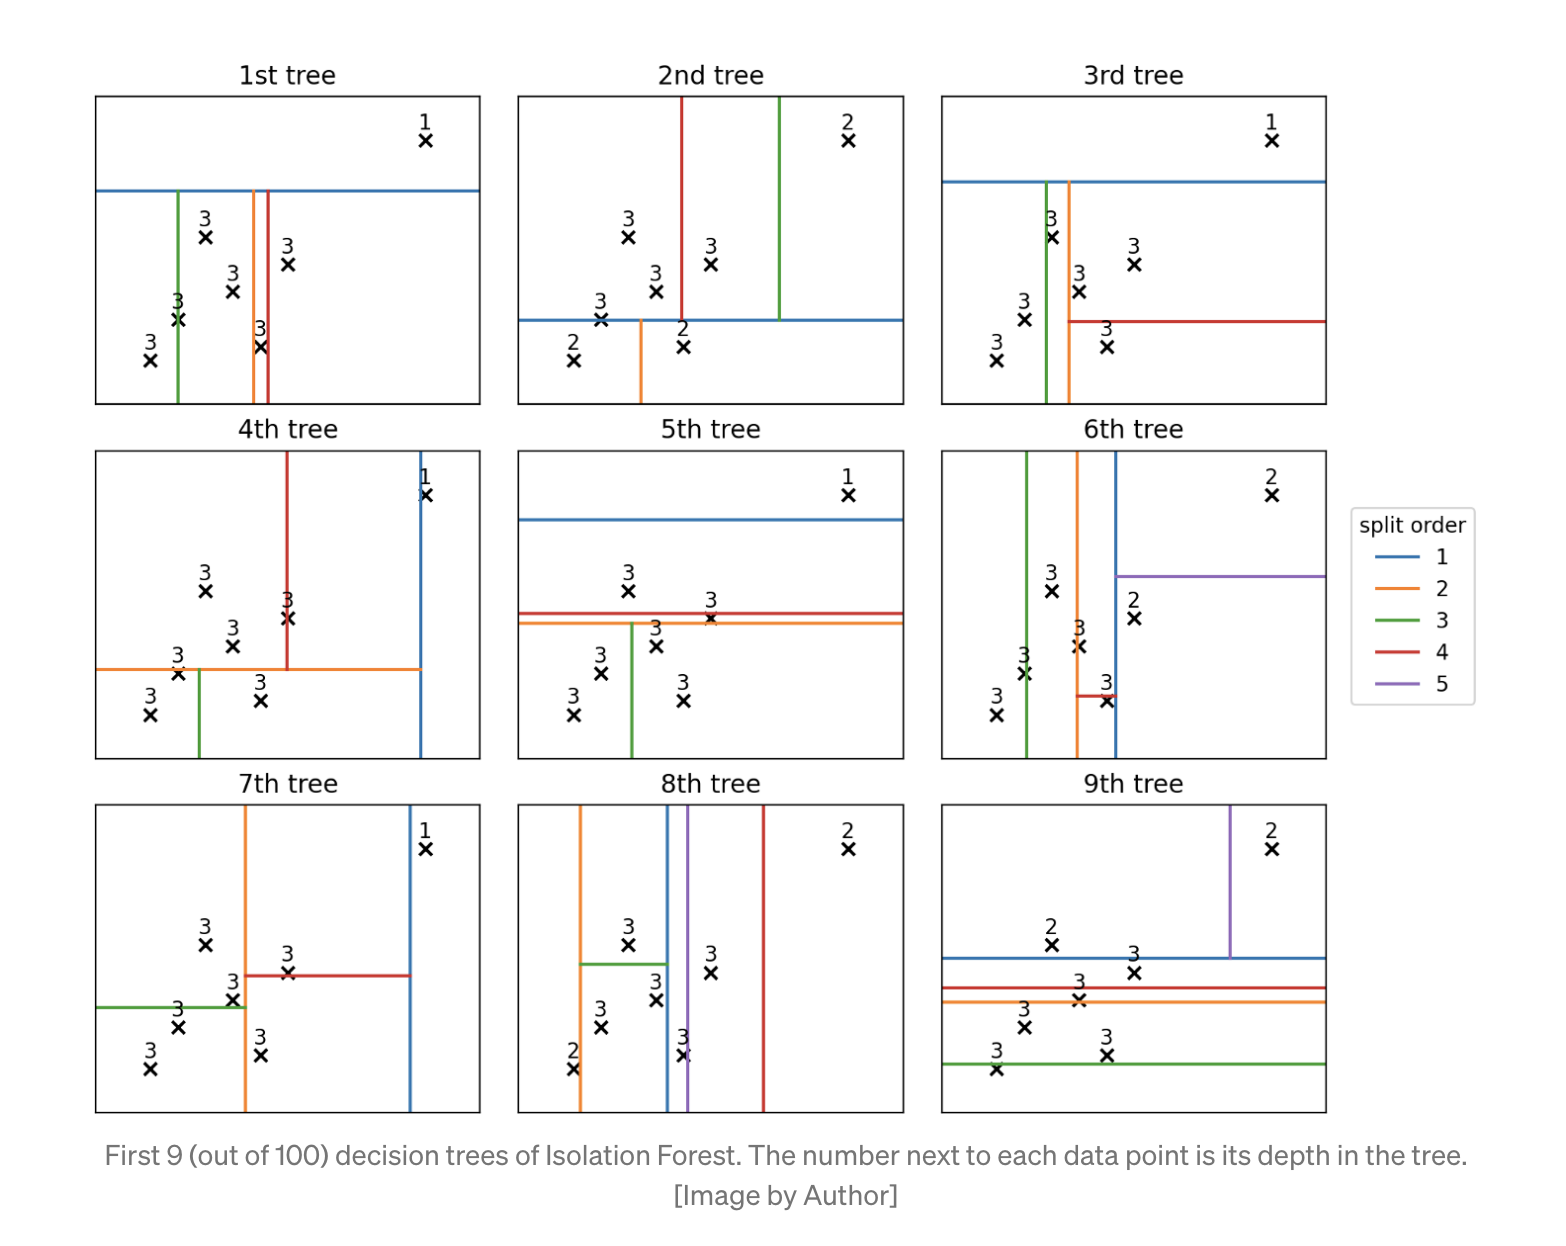

Taking a look at these first 9 trees, we can already see a pattern: G tends to be at a much lower depth (1.44 on average) than any other point. Indeed, the second point is A with an average depth of 2.78.

Conceptually, this is exactly how the algorithm works: a lower average depth means a higher likelihood of being an outlier.

However, in practice, we cannot use average depth, since the depth of a tree depends on the number of samples it has been fit on. For this reason, we need a formula that also take into account the total number of instances. This is the formula proposed in the paper:

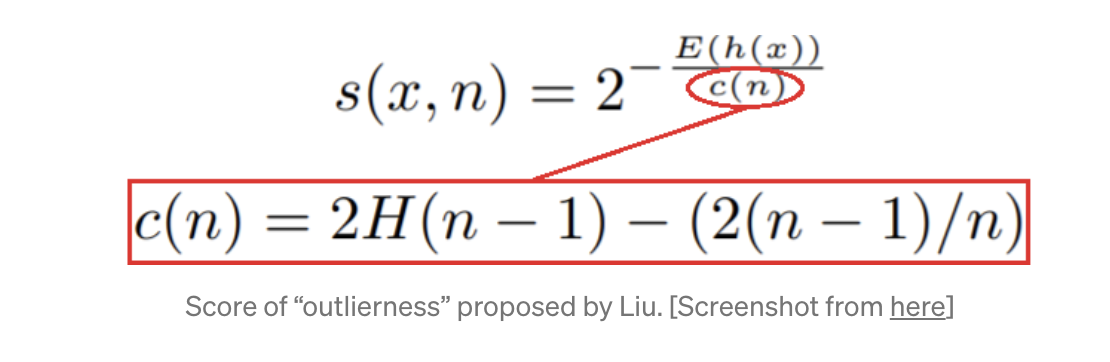

where n is the number of instances, h(x) is the depth at which the data point is found in a particular tree (E(h(x)) is its average over different trees), and H is the armonic number.

s(x, n) is a number between 0 and 1, where the higher the score the more likely it is an outlier.

Note: Scikit-learn’s implementation returns the opposite of the score defined above. So what said above is still valid, but with negative sign.

On our small dataset, the scores are given by:

In [5]:
scores = iforest.score_samples(df)


In [6]:
scores

array([-0.50751552, -0.43559023, -0.46899892, -0.40967668, -0.45172542,
       -0.45522835, -0.68978864])

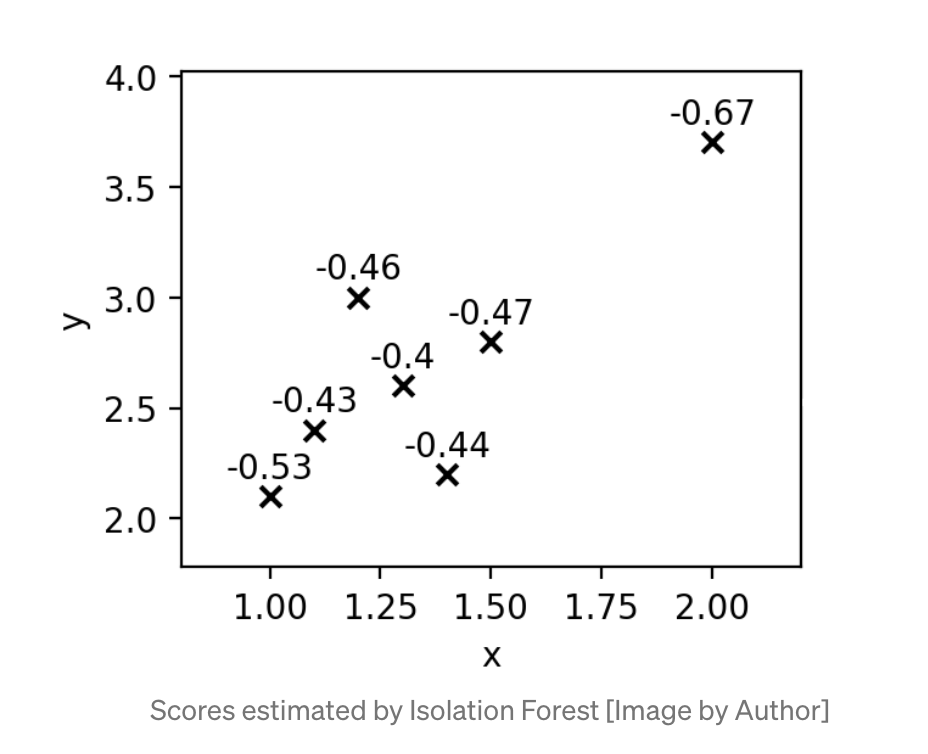

As we expected, G is more likely to be an outlier, since its score is lower than all the other scores.



# Example:

# Anomaly detection

Anomaly detection is the process of identifying unexpected items or events in data sets, which differ from the norm. And anomaly detection is often applied on unlabeled data which is known as unsupervised anomaly detection. 

Anomaly detection has two basic assumptions:
* Anomalies only occur very rarely in the data.
* Their features differ from the normal instances significantly.

## Univariate Anomaly Detection

Before we get to Multivariate anomaly detection, its necessary to work through a simple example of Univariate anomaly detection method in which we detect outliers from a distribution of values in a single feature space.

We are using a super store sales data set, and we are going to find patterns in Sales and Profit separately that do not conform to expected behavior. That is, spotting outliers for one variable at a time.

In [7]:
import pandas as pd
import numpy as np
from numpy import percentile
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.ensemble import IsolationForest

from scipy import stats

In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv
/kaggle/input/super-store/Superstore.csv


In [9]:
df = pd.read_csv("../input/super-store/Superstore.csv")

In [10]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12-06-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Sales Variable Analysis

In [11]:
df.Sales.describe()

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64

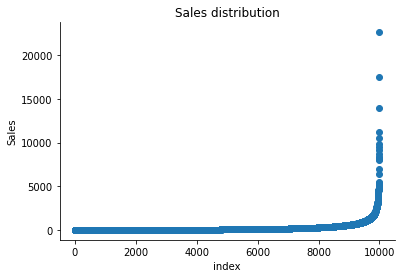

In [12]:
plt.scatter(range(df.shape[0]), np.sort(df['Sales'].values))
plt.xlabel('index')
plt.ylabel('Sales')
plt.title("Sales distribution")
sns.despine()

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


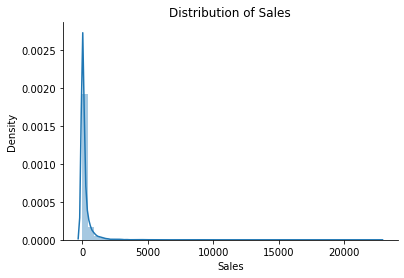

In [13]:
sns.distplot(df['Sales'])
plt.title("Distribution of Sales")
sns.despine()

In [14]:
print("Skewness: %f" % df['Sales'].skew())
print("Kurtosis: %f" % df['Sales'].kurt())

Skewness: 12.972752
Kurtosis: 305.311753


The Superstore’s sales distribution is far from a normal distribution, and it has a positive long thin tail, the mass of the distribution is concentrated on the left of the figure. And the tail sales distribution far exceeds the tails of the normal distribution.
There are one region where the data has low probability to appear which is on the right side of the distribution.

# Profit Variable Analysis

In [15]:
df.Profit.describe()

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

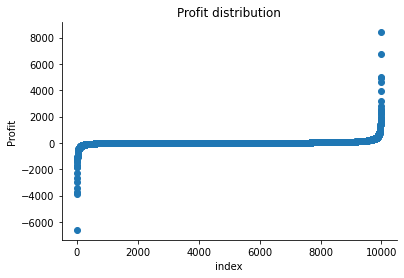

In [16]:
plt.scatter(range(df.shape[0]), np.sort(df['Profit'].values))
plt.xlabel('index')
plt.ylabel('Profit')
plt.title("Profit distribution")
sns.despine()

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


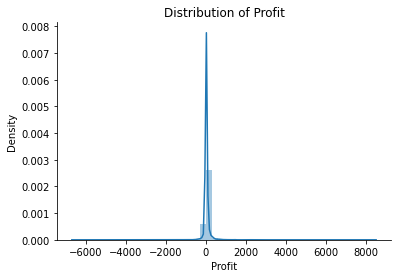

In [17]:
sns.distplot(df['Profit'])
plt.title("Distribution of Profit")
sns.despine()

In [18]:
print("Skewness: %f" % df['Profit'].skew())
print("Kurtosis: %f" % df['Profit'].kurt())

Skewness: 7.561432
Kurtosis: 397.188515


The Superstore’s Profit distribution has both a positive tail and negative tail. However, the positive tail is longer than the negative tail. So the distribution is positive skewed, and the data are heavy-tailed or profusion of outliers.
There are two regions where the data has low probability to appear: one on the right side of the distribution, another one on the left.

### Univariate Anomaly Detection on Sales

## Isolation Forest

Isolation Forest is an algorithm to detect outliers that returns the anomaly score of each sample using the IsolationForest algorithm which is based on the fact that anomalies are data points that are few and different. Isolation Forest is a tree-based model. In these trees, partitions are created by first randomly selecting a feature and then selecting a random split value between the minimum and maximum value of the selected feature.

The following process shows how IsolationForest behaves in the case of the Susperstore’s sales, and the algorithm is implemented in Sklearn:

* Trained IsolationForest using the Sales data.
* Store the Sales in the NumPy array for using in our models later.
* Computed the anomaly score for each observation. The anomaly score of an input sample is computed as the mean anomaly score of the trees in the forest.
* Classified each observation as an outlier or non-outlier.
* The visualization highlights the regions where the outliers fall.

In [19]:
isolation_forest = IsolationForest(n_estimators=100, contamination=0.01)
isolation_forest.fit(df['Sales'].values.reshape(-1, 1))
df['anomaly_score_univariate_sales'] = isolation_forest.decision_function(df['Sales'].values.reshape(-1, 1))
df['outlier_univariate_sales'] = isolation_forest.predict(df['Sales'].values.reshape(-1, 1))

In [20]:
df.sort_values('anomaly_score_univariate_sales')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,anomaly_score_univariate_sales,outlier_univariate_sales
2697,2698,CA-2014-145317,18-03-2014,23-03-2014,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784,-0.112963,-1
6826,6827,CA-2016-118689,02-10-2016,09-10-2016,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760,-0.112963,-1
8153,8154,CA-2017-140151,23-03-2017,25-03-2017,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808,-0.111198,-1
2623,2624,CA-2017-127180,22-10-2017,24-10-2017,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888,-0.105924,-1
9039,9040,CA-2016-117121,17-12-2016,21-12-2016,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700,-0.105340,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6921,6922,CA-2017-109211,04-04-2017,10-04-2017,Standard Class,PS-19045,Penelope Sewall,Home Office,United States,New York City,...,OFF-EN-10001532,Office Supplies,Envelopes,Brown Kraft Recycled Envelopes,16.980,1,0.0,8.4900,0.388648,1
2469,2470,CA-2017-128755,04-05-2017,08-05-2017,Standard Class,MK-18160,Mike Kennedy,Consumer,United States,Newport News,...,OFF-ST-10001291,Office Supplies,Storage,Tenex Personal Self-Stacking Standard File Box...,16.910,1,0.0,4.5657,0.388648,1
5128,5129,CA-2014-160766,14-09-2014,14-09-2014,Same Day,DM-13015,Darrin Martin,Consumer,United States,New York City,...,TEC-PH-10001536,Technology,Phones,Spigen Samsung Galaxy S5 Case Wallet,16.990,1,0.0,4.4174,0.388648,1
2606,2607,CA-2016-154053,04-03-2016,10-03-2016,Standard Class,MG-17890,Michael Granlund,Home Office,United States,San Diego,...,OFF-AR-10003727,Office Supplies,Art,Berol Giant Pencil Sharpener,16.990,1,0.0,4.9271,0.388648,1


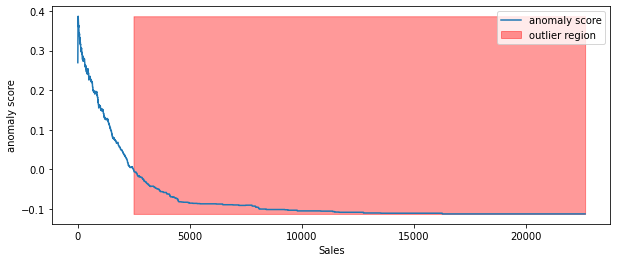

In [21]:
xx = np.linspace(df['Sales'].min(), df['Sales'].max(), len(df)).reshape(-1,1)
anomaly_score = isolation_forest.decision_function(xx)
outlier = isolation_forest.predict(xx)

plt.figure(figsize=(10,4))
plt.plot(xx, anomaly_score, label='anomaly score')
plt.fill_between(xx.T[0], np.min(anomaly_score), np.max(anomaly_score), 
                 where=outlier==-1, color='r', 
                 alpha=.4, label='outlier region')
plt.legend()
plt.ylabel('anomaly score')
plt.xlabel('Sales')
plt.show();

According to the above results and visualization, it seems that sales that exceeds 1500 would be definitely considered as an outlier.

### Anomaly detection on Profit

In [22]:
isolation_forest = IsolationForest(n_estimators=100, contamination=0.01)
isolation_forest.fit(df['Profit'].values.reshape(-1, 1))
df['anomaly_score_univariate_profit'] = isolation_forest.decision_function(df['Profit'].values.reshape(-1, 1))
df['outlier_univariate_profit'] = isolation_forest.predict(df['Profit'].values.reshape(-1, 1))

In [23]:
df.sort_values('anomaly_score_univariate_profit')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,anomaly_score_univariate_sales,outlier_univariate_sales,anomaly_score_univariate_profit,outlier_univariate_profit
8153,8154,CA-2017-140151,23-03-2017,25-03-2017,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808,-0.111198,-1,-0.099023,-1
6826,6827,CA-2016-118689,02-10-2016,09-10-2016,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760,-0.112963,-1,-0.099023,-1
9039,9040,CA-2016-117121,17-12-2016,21-12-2016,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700,-0.105340,-1,-0.097878,-1
4190,4191,CA-2017-166709,17-11-2017,22-11-2017,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856,-0.105340,-1,-0.097878,-1
4098,4099,CA-2014-116904,23-09-2014,28-09-2014,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,...,Binders,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755,-0.103590,-1,-0.096163,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1712,1713,CA-2015-145401,30-01-2015,04-02-2015,Standard Class,JP-15520,Jeremy Pistek,Consumer,United States,Houston,...,Paper,Rediform Voice Mail Log Books,14.304,6,0.2,5.0064,0.383646,1,0.425714,1
7936,7937,CA-2017-166093,17-08-2017,24-08-2017,Standard Class,RW-19540,Rick Wilson,Corporate,United States,Brentwood,...,Binders,Wilson Jones Clip & Carry Folder Binder Tool f...,13.920,3,0.2,4.8720,0.385185,1,0.425714,1
1474,1475,CA-2016-113138,19-11-2016,25-11-2016,Standard Class,NP-18685,Nora Pelletier,Home Office,United States,Niagara Falls,...,Art,Newell 340,17.280,6,0.0,5.0112,0.387960,1,0.425714,1
5406,5407,US-2016-143280,22-02-2016,26-02-2016,Standard Class,TZ-21580,Tracy Zic,Consumer,United States,Los Angeles,...,Fasteners,"Acco Clips to Go Binder Clips, 24 Clips in Two...",10.650,3,0.0,5.0055,0.377740,1,0.425714,1


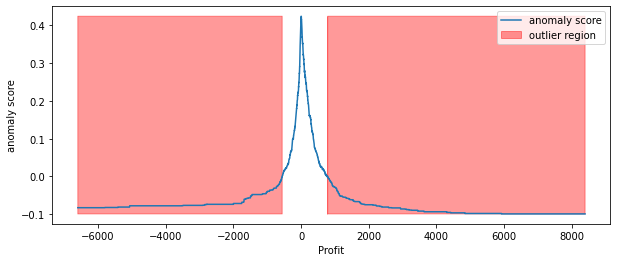

In [24]:
xx = np.linspace(df['Profit'].min(), df['Profit'].max(), len(df)).reshape(-1,1)
anomaly_score = isolation_forest.decision_function(xx)
outlier = isolation_forest.predict(xx)
plt.figure(figsize=(10,4))
plt.plot(xx, anomaly_score, label='anomaly score')
plt.fill_between(xx.T[0], np.min(anomaly_score), np.max(anomaly_score), 
                 where=outlier==-1, color='r', 
                 alpha=.4, label='outlier region')
plt.legend()
plt.ylabel('anomaly score')
plt.xlabel('Profit')
plt.show();

According to the above results and visualization, it seems Profit that is below -100 or exceeds 100 would be considered as an outlier.

In [25]:
df[(df['outlier_univariate_profit']==-1) & (df['outlier_univariate_sales']==-1)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,anomaly_score_univariate_sales,outlier_univariate_sales,anomaly_score_univariate_profit,outlier_univariate_profit
27,28,US-2015-150630,17-09-2015,21-09-2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.430,7,0.5,-1665.0522,-0.035365,-1,-0.060405,-1
165,166,CA-2014-139892,08-09-2014,12-09-2014,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,Machines,Lexmark MX611dhe Monochrome Laser Printer,8159.952,8,0.4,-1359.9920,-0.100682,-1,-0.047768,-1
318,319,CA-2014-164973,04-11-2014,09-11-2014,Standard Class,NM-18445,Nathan Mautz,Home Office,United States,New York City,...,Machines,Canon imageCLASS MF7460 Monochrome Digital Las...,3991.980,2,0.0,1995.9900,-0.062092,-1,-0.074745,-1
353,354,CA-2016-129714,01-09-2016,03-09-2016,First Class,AB-10060,Adam Bellavance,Home Office,United States,New York City,...,Binders,GBC DocuBind P400 Electric Binding System,4355.168,4,0.2,1415.4296,-0.072697,-1,-0.058766,-1
509,510,CA-2015-145352,16-03-2015,22-03-2015,Standard Class,CM-12385,Christopher Martinez,Consumer,United States,Atlanta,...,Binders,Fellowes PB500 Electric Punch Plastic Comb Bin...,6354.950,5,0.0,3177.4750,-0.088002,-1,-0.087643,-1
515,516,CA-2017-127432,22-01-2017,27-01-2017,Standard Class,AD-10180,Alan Dominguez,Home Office,United States,Great Falls,...,Copiers,Canon Image Class D660 Copier,2999.950,5,0.0,1379.9770,-0.031085,-1,-0.057676,-1
683,684,US-2017-168116,04-11-2017,04-11-2017,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904,-0.096049,-1,-0.077532,-1
994,995,CA-2014-117639,21-05-2014,25-05-2014,Standard Class,MW-18235,Mitch Willingham,Corporate,United States,Virginia Beach,...,Binders,Fellowes PB300 Plastic Comb Binding Machine,2715.930,7,0.0,1276.4871,-0.019434,-1,-0.054956,-1
1085,1086,US-2016-143819,01-03-2016,05-03-2016,Standard Class,KD-16270,Karen Daniels,Consumer,United States,Yonkers,...,Machines,Ativa V4110MDD Micro-Cut Shredder,4899.930,7,0.0,2400.9657,-0.084007,-1,-0.080889,-1
1454,1455,CA-2016-133711,26-11-2016,29-11-2016,First Class,MC-17425,Mark Cousins,Corporate,United States,Mobile,...,Machines,Hewlett-Packard Deskjet 3050a All-in-One Color...,3040.000,8,0.0,1459.2000,-0.032153,-1,-0.060952,-1


The above two visualizations show the anomaly scores and highlighted the regions where the outliers are. As expected, the anomaly score reflects the shape of the underlying distribution and the outlier regions correspond to low probability areas.

However, univariate analysis can only get us thus far. We may realize that some of these anomalies that determined by our models are anomalous in context of one variable but not the other. When our data is multidimensional as opposed to univariate, the approaches to anomaly detection become more computationally intensive and more mathematically complex.

# Multivariate Anomaly Detection

Most of the analysis that we end up doing are multivariate due to complexity of the world we are living in. In multivariate anomaly detection, outlier is a combined unusual score on at least two variables.

So, using the Sales and Profit variables, we are going to build an unsupervised multivariate anomaly detection model.

### Sales & Profit

When we are in business, we expect that Sales & Profit are positive correlated. If some of the Sales data points and Profit data points are not positive correlated, they would be considered as outliers and need to be further investigated.

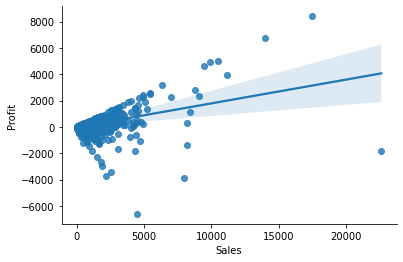

In [26]:
sns.regplot(x="Sales", y="Profit", data=df)
sns.despine();

From the above correlation chart, we can see that some of the data points are obvious outliers such as extreme low and extreme high values.

In [27]:
minmax = MinMaxScaler(feature_range=(0, 1))
X = minmax.fit_transform(df[['Sales','Profit']])

In [28]:
clf = IsolationForest(n_estimators=100, contamination=0.01, random_state=0)
clf.fit(X)

# predict raw anomaly score
df['multivariate_anomaly_score'] = clf.decision_function(X)
        
# prediction of a datapoint category outlier or inlier
df['multivariate_outlier'] = clf.predict(X)

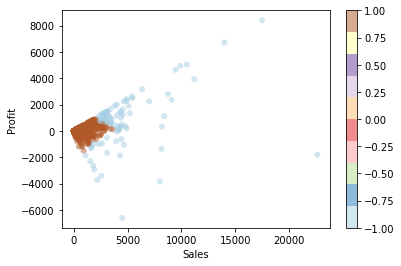

In [29]:
plt.scatter(df['Sales'], df['Profit'],
            c=df.multivariate_outlier, edgecolor='none', alpha=0.5,
            cmap=plt.cm.get_cmap('Paired', 10))
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.colorbar();

In [30]:
df[(df['outlier_univariate_sales'] == 1) & (df['outlier_univariate_profit'] == 1) & (df['multivariate_outlier'] == -1)]


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,anomaly_score_univariate_sales,outlier_univariate_sales,anomaly_score_univariate_profit,outlier_univariate_profit,multivariate_anomaly_score,multivariate_outlier
1001,1002,CA-2015-124891,31-07-2015,31-07-2015,Same Day,RH-19495,Rick Hansen,Consumer,United States,New York City,...,2309.65,7,0.0,762.1845,0.005902,1,0.001600,1,-0.003494,-1
5530,5531,CA-2017-160885,02-12-2017,06-12-2017,Standard Class,JK-16090,Juliana Krohn,Consumer,United States,Omaha,...,2479.96,4,0.0,743.9880,0.000288,1,0.003113,1,-0.010036,-1


### Visually investigate some of the anomalies

We may want to investigate each of the outliers that determined by our model and try to understand what make them anomalies.

# **Outlier detection with Local Outlier Factor (LOF)**

The Local Outlier Factor (LOF) algorithm is an unsupervised anomaly detection method which computes the local density deviation of a given data point with respect to its neighbors. It considers as outliers the samples that have a substantially lower density than their neighbors. This example shows how to use LOF for outlier detection which is the default use case of this estimator in scikit-learn. Note that when LOF is used for outlier detection it has no predict, decision_function and score_samples methods. See User Guide: for details on the difference between outlier detection and novelty detection and how to use LOF for novelty detection.

The number of neighbors considered (parameter n_neighbors) is typically set 1) greater than the minimum number of samples a cluster has to contain, so that other samples can be local outliers relative to this cluster, and 2) smaller than the maximum number of close by samples that can potentially be local outliers. In practice, such information is generally not available, and taking n_neighbors=20 appears to work well in general.



In [31]:
import pandas as pd
import numpy as np
from numpy import percentile
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.neighbors import LocalOutlierFactor
np.random.seed(42)
from scipy import stats

In [32]:
df1 = pd.read_csv("../input/super-store/Superstore.csv")

In [33]:
df1.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,08-11-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,12-06-2016,16-06-2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,11-10-2015,18-10-2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Sales Variable Analysis

In [34]:
df1.Sales.describe()

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64

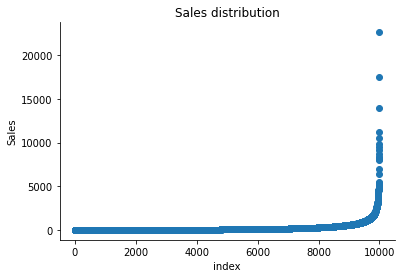

In [35]:
plt.scatter(range(df.shape[0]), np.sort(df['Sales'].values))
plt.xlabel('index')
plt.ylabel('Sales')
plt.title("Sales distribution")
sns.despine()

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


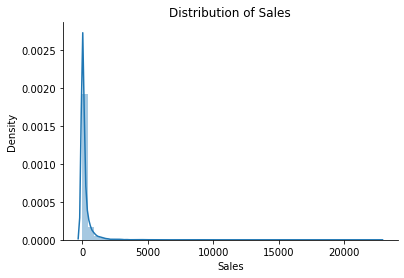

In [36]:
sns.distplot(df['Sales'])
plt.title("Distribution of Sales")
sns.despine()

In [37]:
print("Skewness: %f" % df['Sales'].skew())
print("Kurtosis: %f" % df['Sales'].kurt())

Skewness: 12.972752
Kurtosis: 305.311753


The Superstore’s sales distribution is far from a normal distribution, and it has a positive long thin tail, the mass of the distribution is concentrated on the left of the figure. And the tail sales distribution far exceeds the tails of the normal distribution. There are one region where the data has low probability to appear which is on the right side of the distribution.

# Profit veriable analysis

In [38]:
df1.Profit.describe()

count    9994.000000
mean       28.656896
std       234.260108
min     -6599.978000
25%         1.728750
50%         8.666500
75%        29.364000
max      8399.976000
Name: Profit, dtype: float64

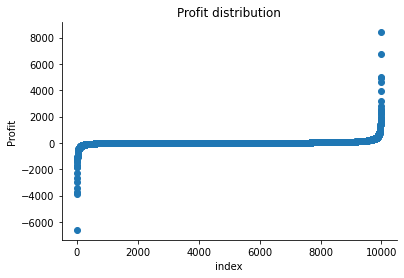

In [39]:
plt.scatter(range(df.shape[0]), np.sort(df['Profit'].values))
plt.xlabel('index')
plt.ylabel('Profit')
plt.title("Profit distribution")
sns.despine()

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


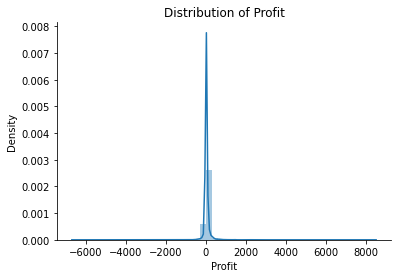

In [40]:
sns.distplot(df['Profit'])
plt.title("Distribution of Profit")
sns.despine()

In [41]:
print("Skewness: %f" % df['Profit'].skew())
print("Kurtosis: %f" % df['Profit'].kurt())

Skewness: 7.561432
Kurtosis: 397.188515


The Superstore’s Profit distribution has both a positive tail and negative tail. However, the positive tail is longer than the negative tail. So the distribution is positive skewed, and the data are heavy-tailed or profusion of outliers. There are two regions where the data has low probability to appear: one on the right side of the distribution, another one on the left.

# **Local Outlier Factor (LOF)**

In [42]:
LocalOutlier_forest = LocalOutlierFactor(n_neighbors=40,novelty=True, contamination=0.01)
LocalOutlier_forest.fit(df1['Sales'].values.reshape(-1, 1))
df1['anomaly_score_univariate_sales'] = LocalOutlier_forest.decision_function(df['Sales'].values.reshape(-1, 1))
df1['outlier_univariate_sales'] = LocalOutlier_forest.predict(df1['Sales'].values.reshape(-1, 1))

In [43]:
df1.sort_values('anomaly_score_univariate_sales')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,anomaly_score_univariate_sales,outlier_univariate_sales
2093,2094,CA-2015-149678,13-04-2015,15-04-2015,Second Class,AW-10840,Anthony Witt,Consumer,United States,Farmington,...,OFF-SU-10004498,Office Supplies,Supplies,Martin-Yale Premier Letter Opener,12.880,1,0.0,0.3864,-5.084750e+08,-1
4974,4975,CA-2016-164896,07-11-2016,12-11-2016,Standard Class,PS-19045,Penelope Sewall,Home Office,United States,Oceanside,...,OFF-PA-10002246,Office Supplies,Paper,"Wirebound Four 2-3/4 x 5 Forms per Page, 400 S...",12.900,2,0.0,6.3210,-4.789125e+08,-1
4028,4029,CA-2017-139311,11-08-2017,13-08-2017,First Class,SF-20965,Sylvia Foulston,Corporate,United States,Bedford,...,OFF-BI-10004209,Office Supplies,Binders,"Fellowes Twister Kit, Gray/Clear, 3/pkg",12.864,8,0.8,-22.5120,-4.617625e+08,-1
5816,5817,CA-2014-124730,26-11-2014,26-11-2014,Same Day,LS-17245,Lynn Smith,Consumer,United States,Utica,...,OFF-BI-10001078,Office Supplies,Binders,"Acco PRESSTEX Data Binder with Storage Hooks, ...",12.912,3,0.2,4.6806,-4.226625e+08,-1
6487,6488,CA-2015-120621,21-03-2015,26-03-2015,Standard Class,JW-16075,Julia West,Consumer,United States,Jacksonville,...,OFF-BI-10000948,Office Supplies,Binders,"GBC Laser Imprintable Binding System Covers, D...",12.843,3,0.7,-9.8463,-3.963375e+08,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9404,9405,CA-2017-141663,13-04-2017,17-04-2017,Standard Class,DP-13105,Dave Poirier,Corporate,United States,Philadelphia,...,OFF-FA-10004076,Office Supplies,Fasteners,Translucent Push Pins by OIC,7.920,5,0.2,1.6830,1.788625e+00,1
1183,1184,CA-2017-138779,14-01-2017,15-01-2017,First Class,RB-19570,Rob Beeghly,Consumer,United States,Jacksonville,...,TEC-PH-10003655,Technology,Phones,Sannysis Cute Owl Design Soft Skin Case Cover ...,7.920,5,0.2,0.6930,1.788625e+00,1
3271,3272,CA-2015-155145,27-12-2015,29-12-2015,Second Class,KN-16450,Kean Nguyen,Corporate,United States,Visalia,...,TEC-AC-10003709,Technology,Accessories,Maxell 4.7GB DVD-R 5/Pack,7.920,8,0.0,3.4848,1.788625e+00,1
4335,4336,CA-2015-154795,20-12-2015,24-12-2015,Standard Class,GZ-14470,Gary Zandusky,Consumer,United States,Bullhead City,...,OFF-EN-10003068,Office Supplies,Envelopes,#6 3/4 Gummed Flap White Envelopes,7.920,1,0.2,2.7720,1.788625e+00,1


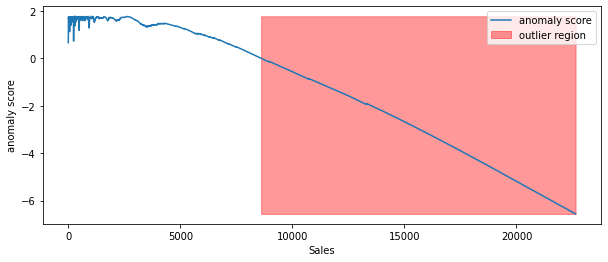

In [44]:
xx = np.linspace(df1['Sales'].min(), df1['Sales'].max(), len(df1)).reshape(-1,1)
anomaly_score = LocalOutlier_forest.decision_function(xx)
outlier = LocalOutlier_forest.predict(xx)

plt.figure(figsize=(10,4))
plt.plot(xx, anomaly_score, label='anomaly score')
plt.fill_between(xx.T[0], np.min(anomaly_score), np.max(anomaly_score), 
                 where=outlier==-1, color='r', 
                 alpha=.4, label='outlier region')
plt.legend()
plt.ylabel('anomaly score')
plt.xlabel('Sales')
plt.show();

In [45]:
LocalOutlier_forest = LocalOutlierFactor(n_neighbors=70,novelty=True, contamination=0.01)
LocalOutlier_forest.fit(df1['Profit'].values.reshape(-1, 1))
df1['anomaly_score_univariate_profit'] = LocalOutlier_forest.decision_function(df1['Profit'].values.reshape(-1, 1))
df1['outlier_univariate_profit'] = LocalOutlier_forest.predict(df1['Profit'].values.reshape(-1, 1))

In [46]:
df1.sort_values('anomaly_score_univariate_profit')

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,anomaly_score_univariate_sales,outlier_univariate_sales,anomaly_score_univariate_profit,outlier_univariate_profit
7772,7773,CA-2016-108196,25-11-2016,02-12-2016,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780,1.427562,1,-18.663660,-1
6826,6827,CA-2016-118689,02-10-2016,09-10-2016,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760,-3.898531,-1,-15.026718,-1
8153,8154,CA-2017-140151,23-03-2017,25-03-2017,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808,-2.212715,-1,-11.319696,-1
683,684,US-2017-168116,04-11-2017,04-11-2017,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904,0.265784,1,-9.482343,-1
9774,9775,CA-2014-169019,26-07-2014,30-07-2014,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928,1.606874,1,-9.036937,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31,32,US-2015-150630,17-09-2015,21-09-2015,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,Art,"BOSTON Model 1800 Electric Pencil Sharpeners, ...",86.304,6,0.2,9.7092,1.704481,1,0.580303,1
1525,1526,CA-2015-144806,06-12-2015,11-12-2015,Standard Class,GH-14425,Gary Hwang,Consumer,United States,Tucson,...,Art,"BOSTON Model 1800 Electric Pencil Sharpeners, ...",86.304,6,0.2,9.7092,1.704481,1,0.580303,1
1761,1762,CA-2015-130785,05-09-2015,09-09-2015,Standard Class,AG-10900,Arthur Gainer,Consumer,United States,San Diego,...,Binders,"DXL Angle-View Binders with Locking Rings, Black",28.752,6,0.2,9.7038,1.676964,1,0.580303,1
8230,8231,CA-2016-162355,30-06-2016,02-07-2016,Second Class,PF-19165,Philip Fox,Consumer,United States,Sandy Springs,...,Art,Bulldog Vacuum Base Pencil Sharpener,35.970,3,0.0,9.7119,1.703422,1,0.580541,1


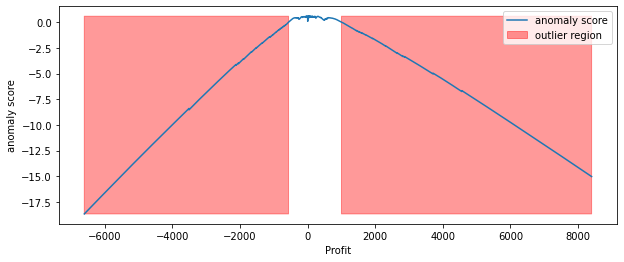

In [47]:
xx = np.linspace(df1['Profit'].min(), df1['Profit'].max(), len(df1)).reshape(-1,1)
anomaly_score = LocalOutlier_forest.decision_function(xx)
outlier = LocalOutlier_forest.predict(xx)
plt.figure(figsize=(10,4))
plt.plot(xx, anomaly_score, label='anomaly score')
plt.fill_between(xx.T[0], np.min(anomaly_score), np.max(anomaly_score), 
                 where=outlier==-1, color='r', 
                 alpha=.4, label='outlier region')
plt.legend()
plt.ylabel('anomaly score')
plt.xlabel('Profit')
plt.show();

In [48]:
df1[(df1['outlier_univariate_profit']==-1) & (df1['outlier_univariate_sales']==-1)]

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,anomaly_score_univariate_sales,outlier_univariate_sales,anomaly_score_univariate_profit,outlier_univariate_profit
2623,2624,CA-2017-127180,22-10-2017,24-10-2017,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,...,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888,-1.045507,-1,-5.384913,-1
2697,2698,CA-2014-145317,18-03-2014,23-03-2014,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,...,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480,6,0.5,-1811.0784,-6.560416,-1,-3.361438,-1
4098,4099,CA-2014-116904,23-09-2014,28-09-2014,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,...,Binders,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755,-0.333846,-1,-6.807210,-1
4190,4191,CA-2017-166709,17-11-2017,22-11-2017,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,...,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856,-0.781242,-1,-7.676603,-1
4277,4278,US-2016-107440,16-04-2016,20-04-2016,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,...,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930,7,0.0,2365.9818,-0.186938,-1,-2.425021,-1
6826,6827,CA-2016-118689,02-10-2016,09-10-2016,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,...,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760,-3.898531,-1,-15.026718,-1
8153,8154,CA-2017-140151,23-03-2017,25-03-2017,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,...,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808,-2.212715,-1,-11.319696,-1
8488,8489,CA-2016-158841,02-02-2016,04-02-2016,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,...,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950,5,0.0,2799.9840,-0.064308,-1,-3.306991,-1
9039,9040,CA-2016-117121,17-12-2016,21-12-2016,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,...,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700,-0.521803,-1,-7.475621,-1


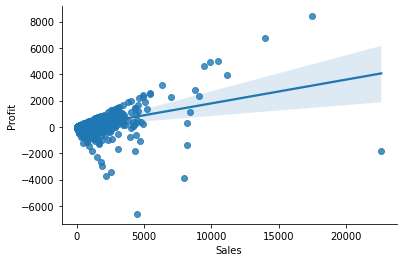

In [49]:
sns.regplot(x="Sales", y="Profit", data=df1)
sns.despine();

From the above correlation chart, we can see that some of the data points are obvious outliers such as extreme low and extreme high values.



In [50]:
inmax = MinMaxScaler(feature_range=(0, 1))
X = minmax.fit_transform(df1[['Sales','Profit']])

In [51]:
clf = IsolationForest(n_estimators=90, contamination=0.01, random_state=0)
clf.fit(X)

# predict raw anomaly score
df1['multivariate_anomaly_score'] = clf.decision_function(X)
        
# prediction of a datapoint category outlier or inlier
df1['multivariate_outlier'] = clf.predict(X)

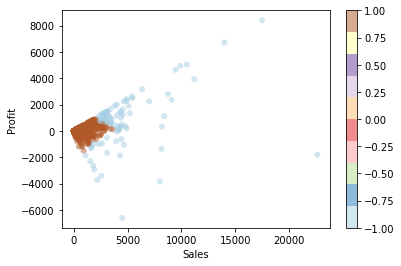

In [52]:
plt.scatter(df1['Sales'], df1['Profit'],
            c=df1.multivariate_outlier, edgecolor='none', alpha=0.5,
            cmap=plt.cm.get_cmap('Paired', 10))
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.colorbar();

In [53]:
df1[(df1['outlier_univariate_sales'] == 1) & (df1['outlier_univariate_profit'] == 1) & (df1['multivariate_outlier'] == -1)]


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sales,Quantity,Discount,Profit,anomaly_score_univariate_sales,outlier_univariate_sales,anomaly_score_univariate_profit,outlier_univariate_profit,multivariate_anomaly_score,multivariate_outlier
251,252,CA-2016-145625,11-09-2016,17-09-2016,Standard Class,KC-16540,Kelly Collister,Consumer,United States,San Diego,...,3347.370,13,0.0,636.0003,1.383719,1,0.431390,1,-0.027635,-1
262,263,US-2014-106992,19-09-2014,21-09-2014,Second Class,SB-20290,Sean Braxton,Corporate,United States,Houston,...,3059.982,3,0.4,-509.9970,1.581409,1,0.142218,1,-0.018486,-1
977,978,CA-2017-159366,07-01-2017,10-01-2017,First Class,BW-11110,Bart Watters,Corporate,United States,Detroit,...,3059.982,2,0.1,679.9960,1.581409,1,0.407350,1,-0.020194,-1
1001,1002,CA-2015-124891,31-07-2015,31-07-2015,Same Day,RH-19495,Rick Hansen,Consumer,United States,New York City,...,2309.650,7,0.0,762.1845,1.669365,1,0.353079,1,-0.003295,-1
1791,1792,CA-2014-120474,01-12-2014,03-12-2014,First Class,RP-19390,Resi Pölking,Consumer,United States,Madison,...,2807.840,8,0.0,673.8816,1.716498,1,0.414061,1,-0.013953,-1
2505,2506,CA-2014-143917,25-07-2014,27-07-2014,Second Class,KL-16645,Ken Lonsdale,Consumer,United States,San Francisco,...,8187.650,5,0.0,327.5060,0.183183,1,0.547852,1,-0.056348,-1
3055,3056,US-2015-100377,28-08-2015,01-09-2015,Standard Class,TS-21370,Todd Sumrall,Corporate,United States,Chicago,...,2799.960,5,0.2,874.9875,1.722279,1,0.218360,1,-0.030517,-1
3070,3071,CA-2014-119375,17-11-2014,22-11-2014,Standard Class,YC-21895,Yoseph Carroll,Corporate,United States,Newark,...,2934.330,7,0.0,792.2691,1.637730,1,0.331060,1,-0.023047,-1
3280,3281,CA-2014-102988,05-04-2014,09-04-2014,Second Class,GM-14695,Greg Maxwell,Corporate,United States,Alexandria,...,4164.050,5,0.0,83.2810,1.464320,1,0.525303,1,-0.004125,-1
3443,3444,CA-2017-168858,19-11-2017,23-11-2017,Standard Class,JD-16150,Justin Deggeller,Corporate,United States,New York City,...,2504.740,7,0.0,626.1850,1.721803,1,0.426485,1,-0.000516,-1
